# WellClass to GaP: build an LGR grid

This notebook is the canonical integration workflow. It demonstrates how a validated WellClass JSON becomes a reviewable GaP local-grid-refinement (LGR) GRDECL file.

The workflow has two inputs:

- **Well input:** a canonical JSON file such as `test_data/examples/wildcat/wildcat.json`. It describes the well header, drilled holes, casings, casing cement, plugs, survey, and stratigraphy.
- **Coarse grid input:** an existing simulator case with matching `.EGRID` and `.INIT` files. GaP refines this grid; it does not yet create or stretch the coarse grid.

The notebook keeps the ownership boundary explicit:

- **WellClass** validates the JSON and derives TVD, borehole, annulus, cement-bond, and plug geometry.
- **WellDataFrame** translates those derived records into the tabular fields expected by the current GaP implementation and requires explicit permeability assumptions.
- **GaP** reads the coarse grid, builds the LGR, assigns material/permeability regions, and writes the GRDECL artifact.

Notebook 1 demonstrates WellClass capabilities, notebook 2 demonstrates GaP capabilities, and this notebook proves the connection between them.

## From JSON to LGR GRDECL

```mermaid
flowchart LR
    JSON[Canonical well JSON] --> Schema[WellModel validation]
    Schema --> Raw[Well]
    Raw --> Processed[WellProcessed]
    Processed --> Derived[Well geometry\nTVD, borehole, annulus, cement, plugs]
    Derived --> Adapter[WellDataFrame\ncompatibility boundary]
    Adapter --> Frames[holes, casings, annulus, barrier regions\nplus explicit permeability]
    Grid[Coarse .EGRID + .INIT] --> Coarse[GridCoarse]
    Frames --> Builder[LGRBuilder]
    Coarse --> Builder
    Builder --> Refine[GridRefine\ncell coordinates and materials]
    Refine --> Artifact[CARFIN / LGR GRDECL]
    Artifact --> Review[Text checks and visual QC]
```

The generated GRDECL is the hand-off artifact. It contains the LGR dimensions, refinement spacing, permeability/material assignments, and closure keywords needed by the downstream simulator workflow. The visual QC below compares the WellClass construction with both the input coarse grid and the generated refined grid.

In [5]:
from pathlib import Path
import tempfile
from src.WellClass.libs.well_class import WellProcessed
from src.WellClass.libs.grid_utils import WellDataFrame, LGRBuilder
from src.WellClass.libs.plotting import plot_grid

root = Path.cwd()
if not (root / 'test_data').exists():
    root = root.parent
well_json = root / 'test_data/examples/wildcat/wildcat.json'
grid_case = root / 'test_data/examples/wildcat/model/TEMP-0'


## Convert input and process the well

In [6]:
processed_well = WellProcessed.from_json(well_json)
well_frames = WellDataFrame(processed_well, oh_perm=10000.0, cb_perm=0.05, barrier_perm=0.05)
print('well:', processed_well.header['unique_wellbore_identifier'])
print('holes:', len(well_frames.holes_df), 'casings:', len(well_frames.casings_df), 'casing cement:', len(processed_well.casing_cement))

well: NO 17/4-1
holes: 5 casings: 3 casing cement: 3


## Build the GaP LGR output

In [7]:
builder = LGRBuilder(str(grid_case), well_frames.annulus_df, well_frames.holes_df, False)
with tempfile.TemporaryDirectory() as output_dir:
    gap_casing = builder.build_grdecl(
        output_dir,
        'SCREEN_LGR',
        well_frames.holes_df,
        well_frames.casings_df,
        well_frames.barrier_regions_df,
    )
    output_file = Path(output_dir) / 'SCREEN_LGR.grdecl'
    print('output:', output_file)
    print('GaP casing rows:', len(gap_casing))
    assert output_file.exists()
print('WellClass to GaP grid checks passed')

Coarse grid dimension: nx=20, ny=20, nz=60
Minimimum grid size is 5.24 cm
LGR dimension: nx=22, ny=22, nz=150
...Prints isolating OVB from reservoir keywords in SCREEN_LGR.grdecl file
...Prints CARFIN Keywords in SCREEN_LGR.grdecl file
...Prints isolating OVB from reservoir in the LGR in SCREEN_LGR.grdecl file
...reopenID = 12.25 ...
Output LGR CARFIN to:  /tmp/tmpt7g3qbcq/SCREEN_LGR.grdecl
output: /tmp/tmpt7g3qbcq/SCREEN_LGR.grdecl
GaP casing rows: 3
WellClass to GaP grid checks passed


## Visual quality control

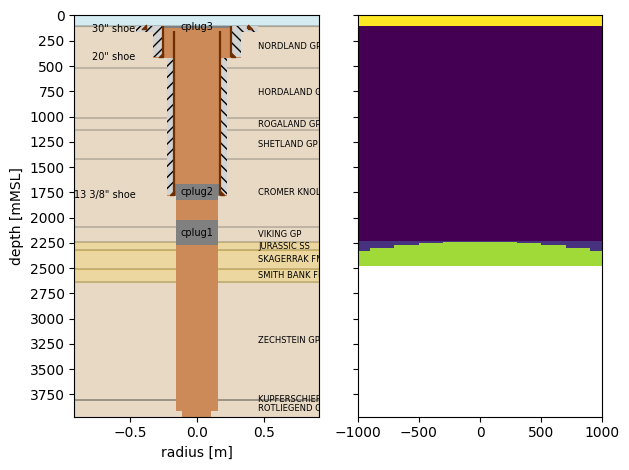

<Figure size 640x480 with 0 Axes>

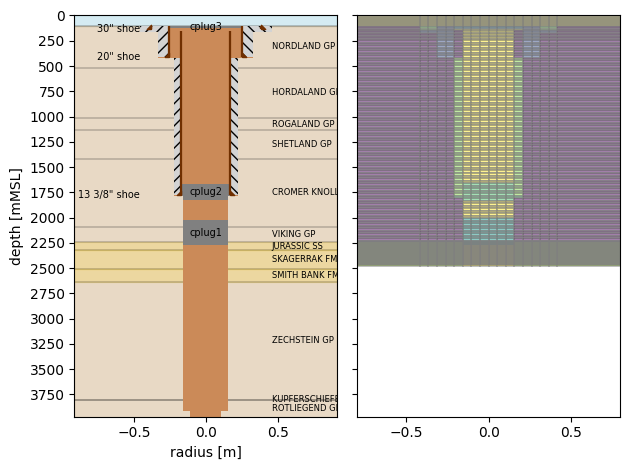

<Figure size 640x480 with 0 Axes>

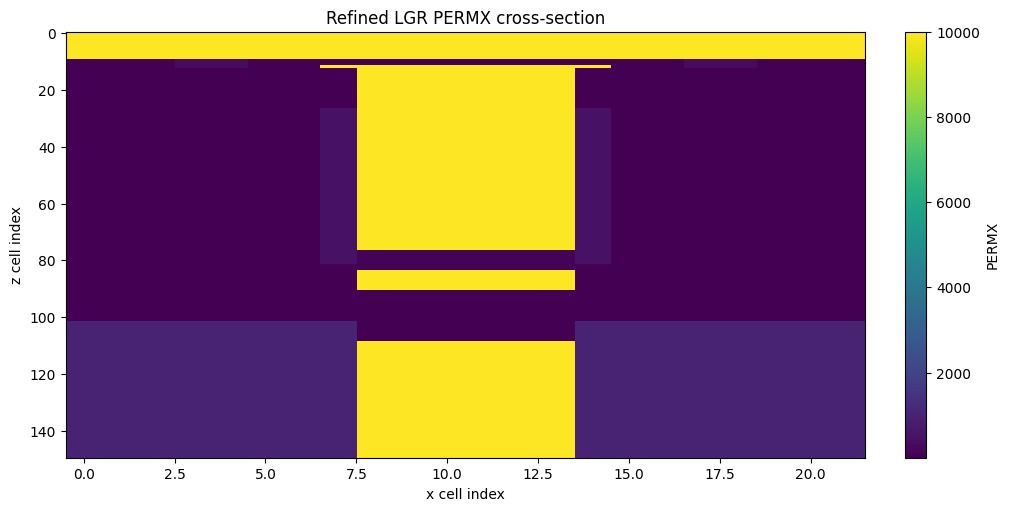

In [8]:
import matplotlib.pyplot as plt

# The same WellProcessed object is overlaid on both grid states, following the
# WellClass/GaP plotting pattern used by the legacy integration notebook.
plot_grid(processed_well, builder.grid_coarse, on_coarse=True)
plt.suptitle('WellClass well over the coarse grid')

plot_grid(processed_well, builder.grid_refine, on_coarse=False)
plt.suptitle('WellClass well over the refined LGR')

# Keep a focused cell-level view for checking the generated PERMX assignment.
mesh = builder.grid_refine.mesh_df
mid_j = int(mesh['j'].max() // 2)
mesh_slice = mesh.query('j == @mid_j').pivot(index='k', columns='i', values='PERMX')
fig, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
image = axis.imshow(mesh_slice, aspect='auto', origin='upper', interpolation='nearest')
axis.set_title('Refined LGR PERMX cross-section')
axis.set_xlabel('x cell index')
axis.set_ylabel('z cell index')
fig.colorbar(image, ax=axis, label='PERMX')
plt.show()
